## Overview
This notebook trains and evaluates two recurrent architectures — **LSTM** and **GRU** — for
next-day closing-price prediction (`HORIZON = 1`) on a basket of Nasdaq technology stocks.
Each architecture is trained in two configurations:
| Configuration | Description |
|---|---|
| **Pooled** | One model trained on all tickers' sequences concatenated |
| **Per-Ticker** | One dedicated model per stock (no cross-ticker mixing) |
This gives **four models** in total, compared head-to-head in Section 11.
---
### Notebook Structure
| Cells | Section | Content |
|---|---|---|
| 1 | Imports | Libraries, `sys.path`, project modules |
| 2–3 | 1. Load Data | Read processed features CSV from Notebook 2 |
| 4–5 | 2. Config | `LOOKBACK = 30`, `HORIZON = 1`, feature columns |
| 6–7 | 3. Split / Scale / Sequences | Per-ticker chronological split → MinMaxScaler (fit on train only) → 3-D LSTM sequences |
| 8–11 | 4. Validate Splits | Date-range table, no-overlap assertion, visualisation |
| 12–13 | 5. Pooled LSTM — Build | 2-layer LSTM (64 → 32 units), Dropout 0.3, Dense(1), Huber loss |
| 14–16 | 6. Pooled LSTM — Train | EarlyStopping (patience 15), ModelCheckpoint → `models/pooled_lstm.keras`, loss curve |
| 17–18 | 7. Per-Ticker LSTM — Train | Independent LSTM per stock → `models/<TICKER>.lstm.keras`, per-ticker loss curves |
| 19–24 | **8. LSTM Evaluation** | Inverse-transform predictions → MAE, RMSE, MAPE (%), Directional Accuracy; Actual vs Predicted plots |
| 25–30 | **9. GRU Models — Build & Train** | Identical architecture to LSTM; pooled (`models/pooled_gru.keras`) + per-ticker (`models/<TICKER>.gru.keras`) |
| 31–35 | **10. GRU Evaluation** | Same metrics and plots as Section 8 |
| 36–37 | **11. All-Model Comparison** | MAPE table + grouped bar chart for all four models |
---
### Design Decisions
- **Time-series safe splitting**: each ticker is split independently (70 / 15 / 15 %) in
  chronological order so future data never leaks into training.
- **Scaler discipline**: `MinMaxScaler` is fit **only on training data** and applied to
  validation and test sets — one scaler stored per ticker for exact inverse-transform.
- **Fair comparison**: LSTM and GRU share the same hyperparameters (layers, units, dropout,
  learning rate, loss function, batch size) so performance differences reflect the architecture.
- **Huber loss**: more robust to price spikes than MSE without sacrificing differentiability.
---
### Key Hyperparameters
| Parameter | Value |
|---|---|
| Lookback window | 30 trading days |
| Forecast horizon | 1 day (next-day close) |
| Target column | `close` |
| Train / Val / Test | 70 % / 15 % / 15 % |
| LSTM / GRU units | 64 → 32 |
| Dropout | 0.3 |
| Optimizer | Adam, lr = 0.0005 |
| Loss | Huber |
| Batch size (pooled) | 64 |
| Batch size (per-ticker) | 32 |
| Max epochs | 200 (early stopping) |
| Early-stopping patience | 15 |
---

In [38]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path.cwd().resolve().parent # Find the root directory, resolve() to get absolute path, parent to go up one level
# Instead of /DL4AI-240166-project-1/notebooks, we want /DL4AI-240166-project-1
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.data.split import train_val_test_split, scale_splits, make_sequences

### 1. Load Processed Features

In [39]:
features_path = Path("/Users/cps/DL4AI-240166-project-1/notebooks/data/nasdaq/csv/tech_nasdaq_stock_data_features.csv")
df_features = pd.read_csv(features_path)
df_features["date"] = pd.to_datetime(df_features["date"])
df_features = df_features.sort_values(["ticker", "date"]).reset_index(drop=True)

print("Shape:", df_features.shape)
print("Tickers:", df_features["ticker"].unique().tolist())
print("Columns:", df_features.columns.tolist())
df_features.head(3)

Shape: (22689, 20)
Tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'MU', 'NFLX', 'NVDA', 'QCOM']
Columns: ['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'log_return', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'atr', 'ema_10', 'ema_20', 'ema_50', 'bb_upper', 'bb_middle', 'bb_lower', 'ticker']


,date,open,high,low,close,adj_close,volume,log_return,rsi,macd,macd_signal,macd_hist,atr,ema_10,ema_20,ema_50,bb_upper,bb_middle,bb_lower,ticker
0,2016-03-15,25.990000,26.295000,25.962500,26.145000,23.685328,160270800,0.019894,67.377844,0.384964,0.249910,0.135054,0.516683,25.419239,25.049804,24.913412,26.286548,24.859875,23.433202,AAPL
1,2016-03-16,26.152500,26.577499,26.147499,26.492500,24.000132,153214000,0.013204,70.323953,0.449557,0.289839,0.159717,0.510670,25.614377,25.187203,24.975337,26.541733,24.958000,23.374267,AAPL
2,2016-03-17,26.379999,26.617500,26.240000,26.450001,23.961632,137682800,-0.001605,69.497309,0.491650,0.330202,0.161449,0.501157,25.766309,25.307470,25.033167,26.731654,25.077250,23.422846,AAPL


### 2. Config

In [40]:
LOOKBACK    = 30
HORIZON     = 1      # 1 = next-day prediction (Task x.1 baseline)
TARGET_COL  = "close"
TRAIN_RATIO = 0.7
VAL_RATIO   = 0.15

# feature columns used for scaling and model input
FEATURE_COLS = [c for c in df_features.columns if c not in ["ticker", "date"]]

### 3. Per-Ticker Split → Scale → Sequences

We must process each ticker independently to avoid cross-ticker sequence contamination.

In [41]:
target_idx = FEATURE_COLS.index(TARGET_COL)

ticker_names  = []          # ordered ticker list — reused by per-ticker training
scalers_list  = []          # one scaler per ticker — needed for inverse-transform

X_train_list, y_train_list = [], []
X_val_list,   y_val_list   = [], []
X_test_list,  y_test_list  = [], []

split_info = []

for ticker, group in df_features.groupby("ticker"):
    g = group.sort_values("date").reset_index(drop=True)

    # 1) chronological split
    train, val, test = train_val_test_split(g, TRAIN_RATIO, VAL_RATIO)

    # 2) scale (fit on train only)
    train_s, val_s, test_s, scaler = scale_splits(train, val, test, FEATURE_COLS)

    # 3) build sequences
    X_tr, y_tr = make_sequences(train_s, LOOKBACK, HORIZON, target_idx)
    X_va, y_va = make_sequences(val_s,   LOOKBACK, HORIZON, target_idx)
    X_te, y_te = make_sequences(test_s,  LOOKBACK, HORIZON, target_idx)

    ticker_names.append(ticker)
    scalers_list.append(scaler)

    X_train_list.append(X_tr); y_train_list.append(y_tr)
    X_val_list.append(X_va);   y_val_list.append(y_va)
    X_test_list.append(X_te);  y_test_list.append(y_te)

    split_info.append({
        "ticker": ticker,
        "train_start": train["date"].min(), "train_end": train["date"].max(),
        "val_start":   val["date"].min(),   "val_end":   val["date"].max(),
        "test_start":  test["date"].min(),  "test_end":  test["date"].max(),
        "X_train": X_tr.shape[0], "X_val": X_va.shape[0], "X_test": X_te.shape[0],
    })

# ── Pooled arrays (all tickers concatenated) ─────────────────────────────────
X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)
X_val   = np.concatenate(X_val_list,   axis=0)
y_val   = np.concatenate(y_val_list,   axis=0)
X_test  = np.concatenate(X_test_list,  axis=0)
y_test  = np.concatenate(y_test_list,  axis=0)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

X_train: (15606, 30, 18)  y_train: (15606, 1)
X_val:   (3132, 30, 18)    y_val:   (3132, 1)
X_test:  (3141, 30, 18)   y_test:  (3141, 1)


### 4. Validate Splits

In [42]:
# 4a) Split date ranges per ticker
info_df = pd.DataFrame(split_info)
display(info_df)

,ticker,train_start,train_end,val_start,val_end,test_start,test_end,X_train,X_val,X_test
0,AAPL,2016-03-15,2023-03-16,2023-03-17,2024-09-17,2024-09-18,2026-03-24,1734,348,349
1,AMZN,2016-03-15,2023-03-16,2023-03-17,2024-09-17,2024-09-18,2026-03-24,1734,348,349
2,GOOGL,2016-03-15,2023-03-16,2023-03-17,2024-09-17,2024-09-18,2026-03-24,1734,348,349
3,META,2016-03-15,2023-03-16,2023-03-17,2024-09-17,2024-09-18,2026-03-24,1734,348,349
4,MSFT,2016-03-15,2023-03-16,2023-03-17,2024-09-17,2024-09-18,2026-03-24,1734,348,349
5,MU,2016-03-15,2023-03-16,2023-03-17,2024-09-17,2024-09-18,2026-03-24,1734,348,349
6,NFLX,2016-03-15,2023-03-16,2023-03-17,2024-09-17,2024-09-18,2026-03-24,1734,348,349
7,NVDA,2016-03-15,2023-03-16,2023-03-17,2024-09-17,2024-09-18,2026-03-24,1734,348,349
8,QCOM,2016-03-15,2023-03-16,2023-03-17,2024-09-17,2024-09-18,2026-03-24,1734,348,349


In [43]:
# 4b) No-overlap assertion per ticker
for row in split_info:
    assert row["train_end"] < row["val_start"],  f"{row['ticker']}: train/val overlap!"
    assert row["val_end"]   < row["test_start"], f"{row['ticker']}: val/test overlap!"
print("No overlap confirmed for all tickers")

No overlap confirmed for all tickers


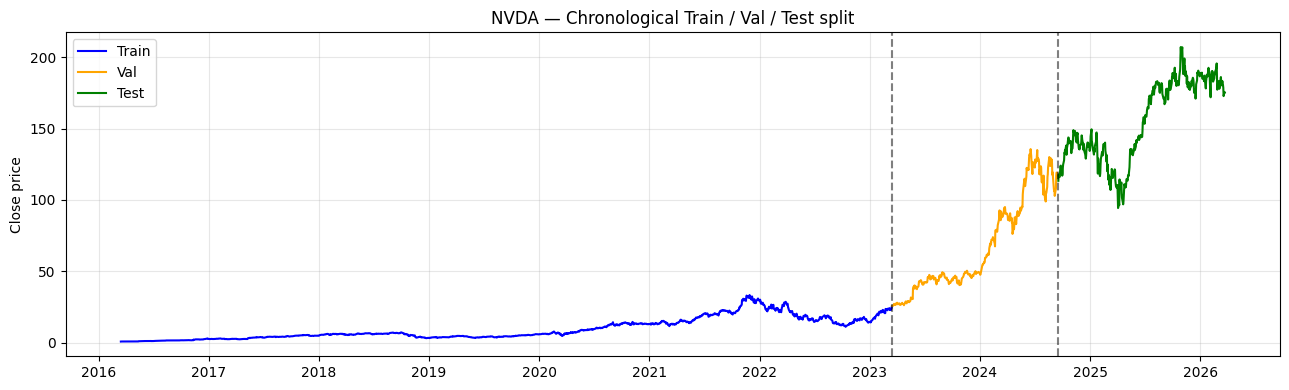

Train: 2016-03-15 → 2023-03-16  (1764 rows)
Val:   2023-03-17 → 2024-09-17  (378 rows)
Test:  2024-09-18 → 2026-03-24  (379 rows)


In [44]:
# 4c) Visualise split for one ticker
PLOT_TICKER = "NVDA"
g = df_features[df_features["ticker"] == PLOT_TICKER].sort_values("date")
tr, va, te = train_val_test_split(g, TRAIN_RATIO, VAL_RATIO)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(tr["date"], tr[TARGET_COL], color="blue",   label="Train")
ax.plot(va["date"], va[TARGET_COL], color="orange", label="Val")
ax.plot(te["date"], te[TARGET_COL], color="green",  label="Test")
ax.axvline(tr["date"].max(), color="black", linestyle="--", alpha=0.5)
ax.axvline(va["date"].max(), color="black", linestyle="--", alpha=0.5)
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title(f"{PLOT_TICKER} — Chronological Train / Val / Test split")
ax.set_ylabel("Close price")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Train: {tr['date'].min().date()} → {tr['date'].max().date()}  ({len(tr)} rows)")
print(f"Val:   {va['date'].min().date()} → {va['date'].max().date()}  ({len(va)} rows)")
print(f"Test:  {te['date'].min().date()} → {te['date'].max().date()}  ({len(te)} rows)")

### 5. BUILD THE LSTM MODEL FOR PREDICTING STOCK IN NASDAQ MARKET

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input, GRU 
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint

# ── Pooled model  (trained on concatenated data from all tickers) ─────────────
N_FEATURES   = X_train.shape[2]

pooled_model = Sequential([
    Input(shape=(LOOKBACK, N_FEATURES)),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(HORIZON),          # Dense(1) for next-day prediction
])

pooled_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="huber",            # more robust to outliers than MSE
)

pooled_model.summary()

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_100 (LSTM)                 │ (None, 30, 64)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_100 (Dropout)           │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_101 (LSTM)                 │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_101 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,895 (132.40 KB)

 Trainable params: 33,895 (132.40 KB)

 Non-trainable params: 0 (0.00 B)

### 6. TRAINING MODEL

In [46]:
# ── Callbacks for the pooled model ───────────────────────────────────────────
pooled_ckpt = ModelCheckpoint(
    "../models/pooled_lstm.keras",
    monitor="val_loss", save_best_only=True, mode="min", verbose=0,
)

pooled_es = EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True,
)

Epoch 1/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0077 - val_loss: 0.0809
Epoch 2/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0028 - val_loss: 0.0732
Epoch 3/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0023 - val_loss: 0.0697
Epoch 4/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0021 - val_loss: 0.0668
Epoch 5/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0018 - val_loss: 0.0646
Epoch 6/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0016 - val_loss: 0.0654
Epoch 7/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0015 - val_loss: 0.0603
Epoch 8/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0014 - val_loss: 0.0622
Epoch 9/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0013 - val_loss: 0.0601
Epoch 10/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0012 - val_loss: 0.0588
Epoch 11/200
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0011 - val_loss: 0.0592
Epoch 12/200
244/244 ━━━━━━━━━

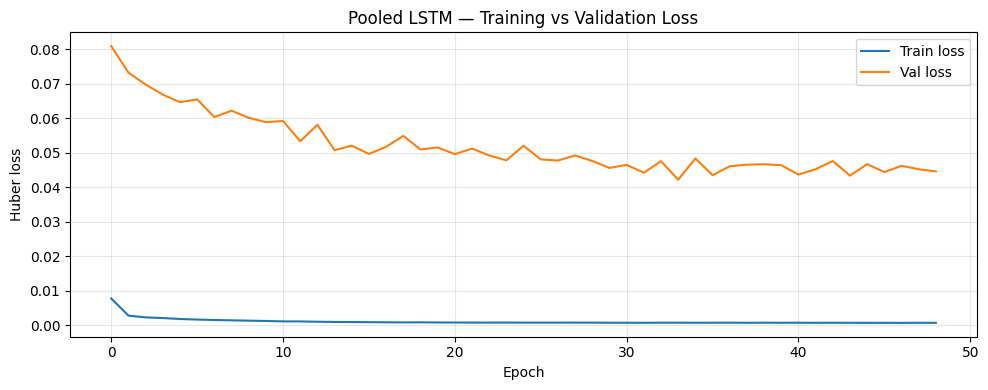

Stopped at epoch 49 | best val_loss = 0.042159


In [47]:
# ── Train the pooled model ────────────────────────────────────────────────────
pooled_history = pooled_model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[pooled_ckpt, pooled_es],
    verbose=1,
)

# ── Loss curve ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pooled_history.history["loss"],     label="Train loss")
ax.plot(pooled_history.history["val_loss"], label="Val loss")
ax.set_title("Pooled LSTM — Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Huber loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

epochs_run = len(pooled_history.history["loss"])
best_val   = min(pooled_history.history["val_loss"])
print(f"Stopped at epoch {epochs_run} | best val_loss = {best_val:.6f}")

### 7. Per-Ticker LSTM  (one dedicated model per stock, HORIZON = 1)

Each ticker gets its own model trained **only on that stock's data** — no cross-ticker contamination.  
Sequences come from the pre-built `X_train_list` / `y_train_list` lists (same split ratios as the pooled model).  
Each model is saved to `models/{TICKER}.lstm.keras`.


  Training per-ticker LSTM: AAPL  (1/9)
  X_train: (1734, 30, 18)  y_train: (1734, 1)
  X_val  : (348, 30, 18)  y_val  : (348, 1)
  Stopped at epoch  29  |  best val_loss = 0.001401


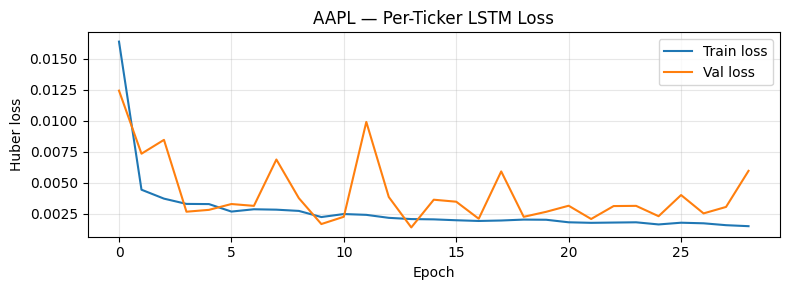


  Training per-ticker LSTM: AMZN  (2/9)
  X_train: (1734, 30, 18)  y_train: (1734, 1)
  X_val  : (348, 30, 18)  y_val  : (348, 1)
  Stopped at epoch  31  |  best val_loss = 0.000419


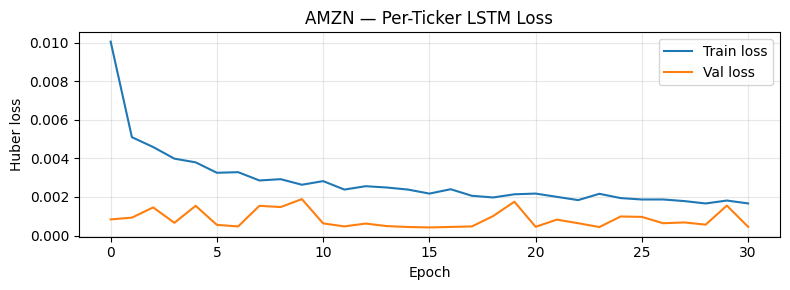


  Training per-ticker LSTM: GOOGL  (3/9)
  X_train: (1734, 30, 18)  y_train: (1734, 1)
  X_val  : (348, 30, 18)  y_val  : (348, 1)
  Stopped at epoch  30  |  best val_loss = 0.001080


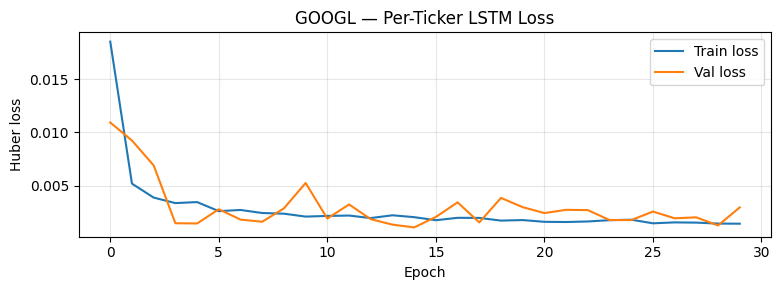


  Training per-ticker LSTM: META  (4/9)
  X_train: (1734, 30, 18)  y_train: (1734, 1)
  X_val  : (348, 30, 18)  y_val  : (348, 1)
  Stopped at epoch  21  |  best val_loss = 0.003321


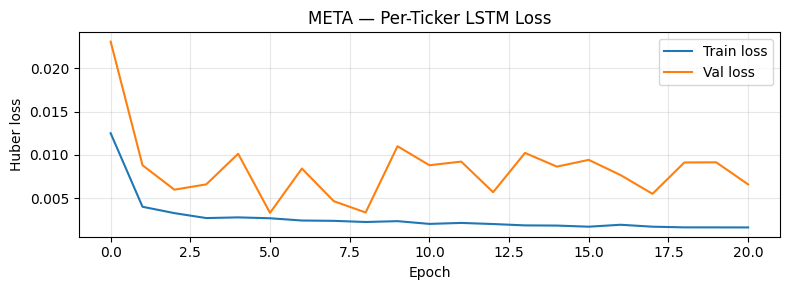


  Training per-ticker LSTM: MSFT  (5/9)
  X_train: (1734, 30, 18)  y_train: (1734, 1)
  X_val  : (348, 30, 18)  y_val  : (348, 1)
  Stopped at epoch  20  |  best val_loss = 0.001203


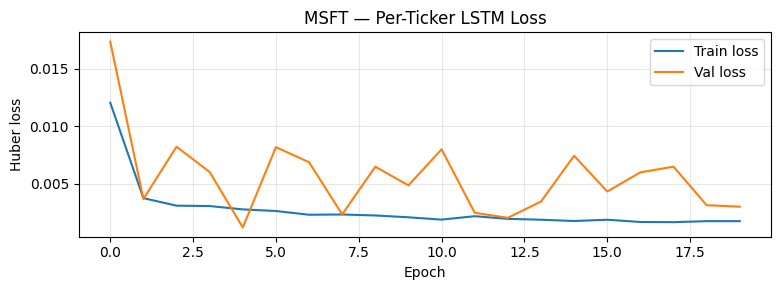


  Training per-ticker LSTM: MU  (6/9)
  X_train: (1734, 30, 18)  y_train: (1734, 1)
  X_val  : (348, 30, 18)  y_val  : (348, 1)
  Stopped at epoch  61  |  best val_loss = 0.001654


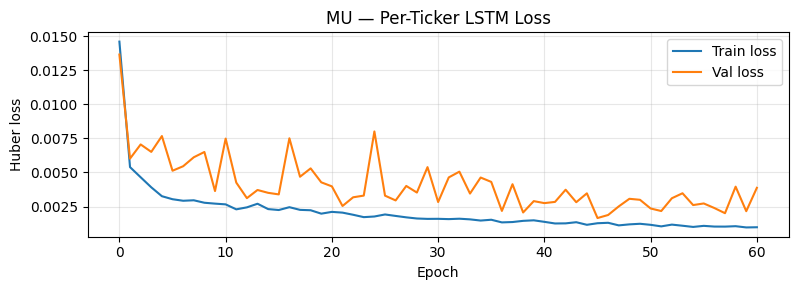


  Training per-ticker LSTM: NFLX  (7/9)
  X_train: (1734, 30, 18)  y_train: (1734, 1)
  X_val  : (348, 30, 18)  y_val  : (348, 1)
  Stopped at epoch 152  |  best val_loss = 0.000194


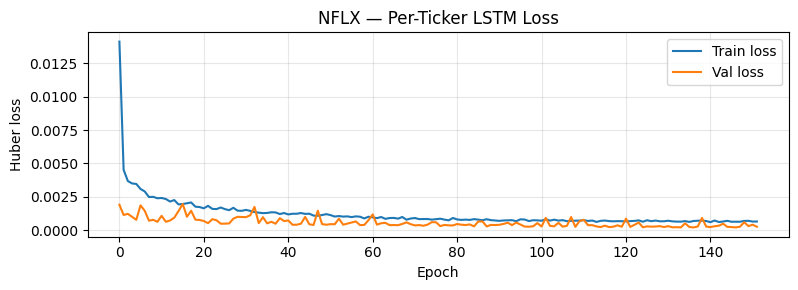


  Training per-ticker LSTM: NVDA  (8/9)
  X_train: (1734, 30, 18)  y_train: (1734, 1)
  X_val  : (348, 30, 18)  y_val  : (348, 1)
  Stopped at epoch  71  |  best val_loss = 0.427133


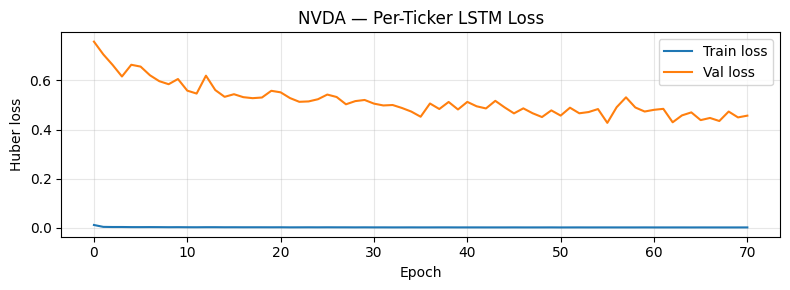


  Training per-ticker LSTM: QCOM  (9/9)
  X_train: (1734, 30, 18)  y_train: (1734, 1)
  X_val  : (348, 30, 18)  y_val  : (348, 1)
  Stopped at epoch 111  |  best val_loss = 0.000447


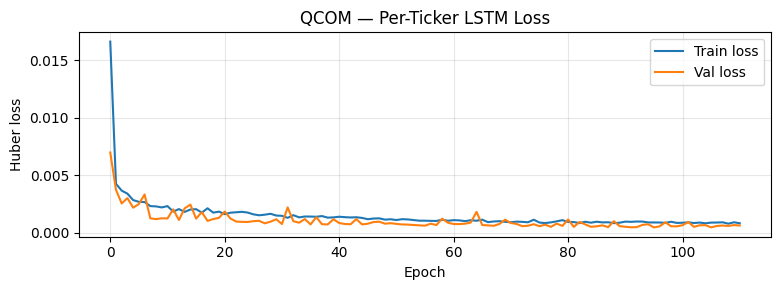


All per-ticker models trained and saved to models/


In [48]:
ticker_histories = {}   # store history objects for later comparison

for i, ticker in enumerate(ticker_names):
    print(f"\n{'='*55}")
    print(f"  Training per-ticker LSTM: {ticker}  ({i+1}/{len(ticker_names)})")
    print(f"{'='*55}")

    X_tr = X_train_list[i]
    y_tr = y_train_list[i]
    X_va = X_val_list[i]
    y_va = y_val_list[i]

    print(f"  X_train: {X_tr.shape}  y_train: {y_tr.shape}")
    print(f"  X_val  : {X_va.shape}  y_val  : {y_va.shape}")

    # ── Build a fresh model for each ticker ──────────────────────────────────
    ticker_model = Sequential([
        Input(shape=(LOOKBACK, X_tr.shape[2])),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32, return_sequences=False),
        Dropout(0.3),
        Dense(HORIZON),
    ])
    ticker_model.compile(optimizer=Adam(learning_rate=0.0005), loss="huber")

    # ── Callbacks ─────────────────────────────────────────────────────────────
    ckpt_path = f"../models/{ticker}.lstm.keras"
    ckpt = ModelCheckpoint(ckpt_path, monitor="val_loss",
                           save_best_only=True, mode="min", verbose=0)
    es   = EarlyStopping(monitor="val_loss", patience=15,
                         restore_best_weights=True)

    # ── Train ─────────────────────────────────────────────────────────────────
    hist = ticker_model.fit(
        X_tr, y_tr,
        epochs=200,
        batch_size=32,
        validation_data=(X_va, y_va),
        callbacks=[ckpt, es],
        verbose=0,
    )

    ticker_histories[ticker] = hist.history
    epochs_run = len(hist.history["loss"])
    best_val   = min(hist.history["val_loss"])
    print(f"  Stopped at epoch {epochs_run:3d}  |  best val_loss = {best_val:.6f}")

    # ── Loss curve ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(hist.history["loss"],     label="Train loss")
    ax.plot(hist.history["val_loss"], label="Val loss")
    ax.set_title(f"{ticker} — Per-Ticker LSTM Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Huber loss")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\nAll per-ticker models trained and saved to models/")

### 8. LSTM — Test-Set Evaluation

Predictions are **inverse-transformed** back to original USD price before computing metrics,  
so MAE / RMSE are interpretable in dollars.  
Metrics: **MAE**, **RMSE**, **MAPE (%)**, **Directional Accuracy**.

| Metric | Meaning |
|--------|---------|
| **MAE** | Mean Absolute Error in USD |
| **RMSE** | Root Mean Squared Error in USD |
| **MAPE (%)** | Mean Absolute Percentage Error |
| **Directional Acc** | Fraction of days where predicted direction (up/down) matches actual |

In [49]:
from keras.models import load_model
from src.evaluation.regression_metrics import evaluate_forecast


def inverse_transform_col(y_scaled, scaler, col_idx, n_features):
    """Inverse-transform a single-column prediction back to original scale."""
    dummy = np.zeros((len(y_scaled), n_features))
    dummy[:, col_idx] = np.array(y_scaled).flatten()
    return scaler.inverse_transform(dummy)[:, col_idx]


N_FEATURES = len(FEATURE_COLS)

#### 8a. Pooled model — test-set predictions

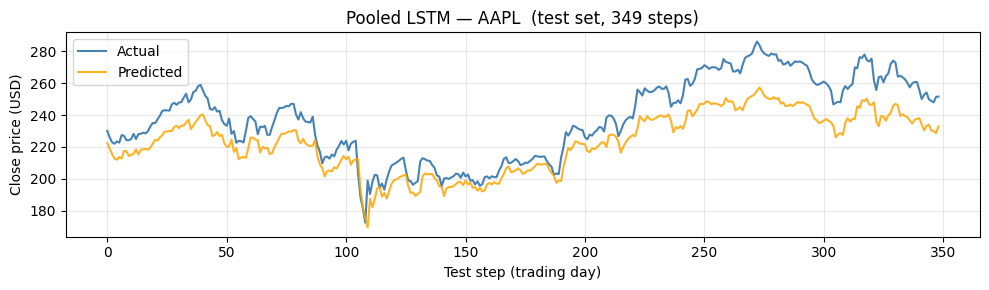

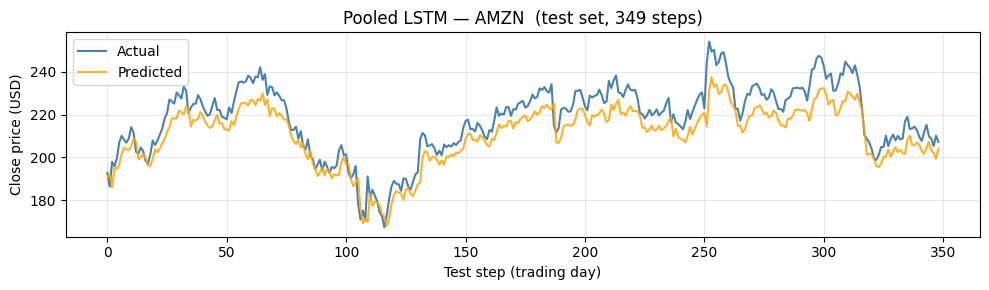

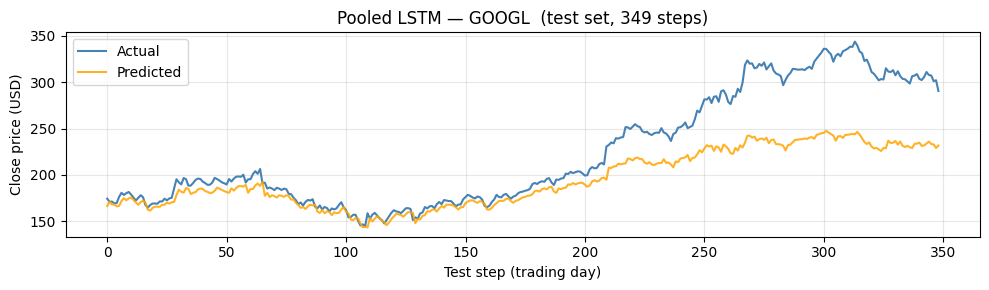

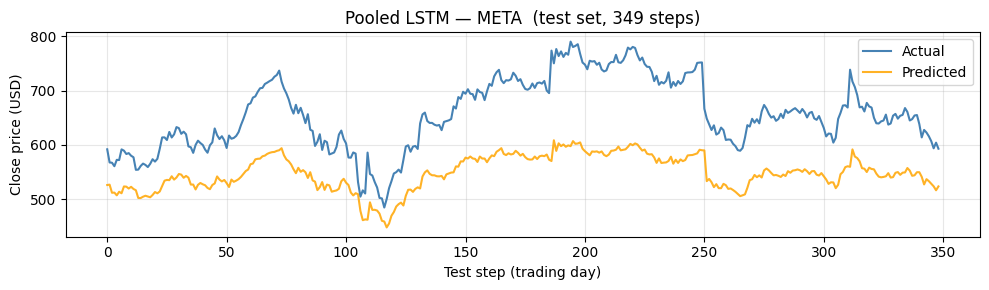

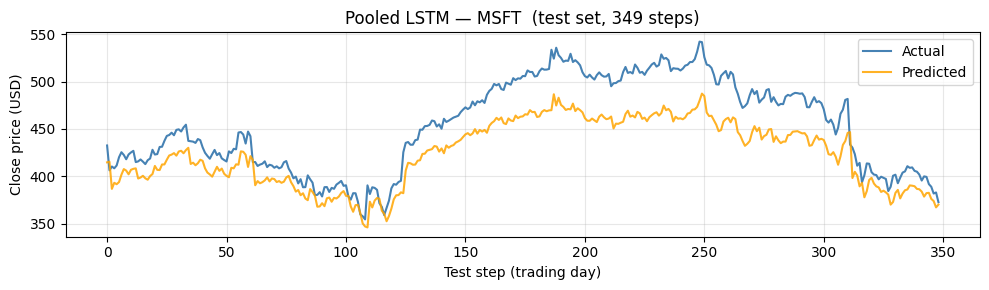

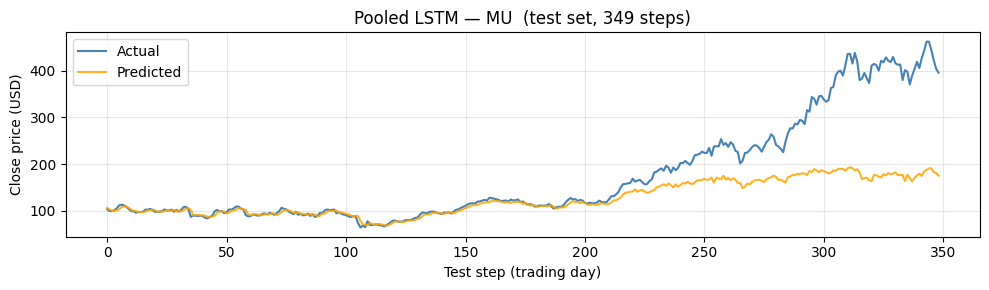

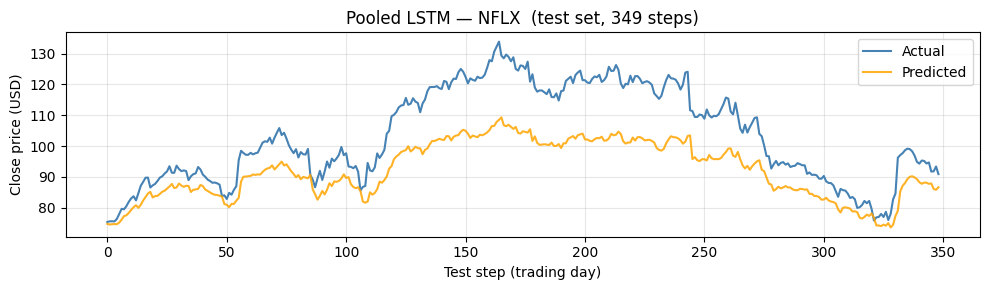

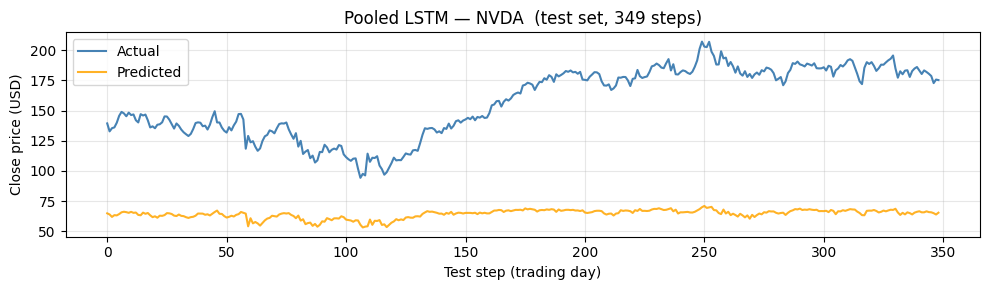

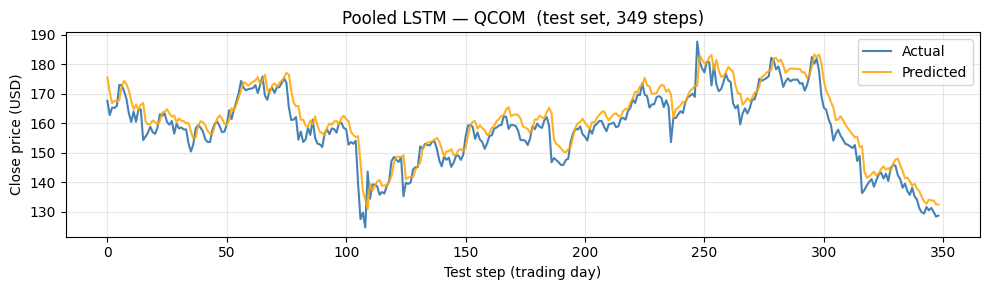


Pooled LSTM — Summary metrics on test set
             MAE      RMSE  MAPE (%)  Directional Acc
Ticker                                               
AAPL     14.6945   16.6337    5.9404           0.5287
AMZN      7.6164    8.7457    3.4288           0.4713
GOOGL    29.4794   42.7502   10.6795           0.5029
META    107.9259  113.6229   16.0818           0.4971
MSFT     29.5406   33.2437    6.2531           0.4856
MU       49.5447   92.4138   16.4568           0.5201
NFLX     11.2719   13.0050   10.2375           0.5230
NVDA     92.6130   96.1074   57.8323           0.4569
QCOM      3.6378    4.7549    2.3426           0.4713


In [50]:
# Raw scaled predictions for the full concatenated test set
y_pred_pooled_scaled = pooled_model.predict(X_test, verbose=0).flatten()
y_true_pooled_scaled = y_test.flatten()

results_pooled = []
offset = 0

for i, ticker in enumerate(ticker_names):
    n = X_test_list[i].shape[0]

    y_pred_s = y_pred_pooled_scaled[offset : offset + n]
    y_true_s = y_true_pooled_scaled[offset : offset + n]

    # Inverse-transform back to USD
    y_pred = inverse_transform_col(y_pred_s, scalers_list[i], target_idx, N_FEATURES)
    y_true = inverse_transform_col(y_true_s, scalers_list[i], target_idx, N_FEATURES)

    metrics = evaluate_forecast(y_true, y_pred)
    metrics["Ticker"] = ticker
    results_pooled.append(metrics)

    # Actual vs Predicted plot
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(y_true, label="Actual",    color="steelblue")
    ax.plot(y_pred, label="Predicted", color="orange", alpha=0.85)
    ax.set_title(f"Pooled LSTM — {ticker}  (test set, {n} steps)")
    ax.set_xlabel("Test step (trading day)")
    ax.set_ylabel("Close price (USD)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    offset += n

df_pooled = pd.DataFrame(results_pooled).set_index("Ticker")
print("\nPooled LSTM — Summary metrics on test set")
print(df_pooled.to_string())

#### 8b. Per-ticker models — test-set predictions

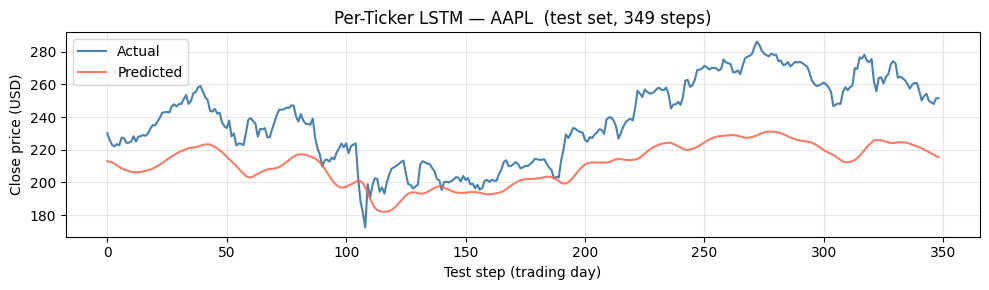

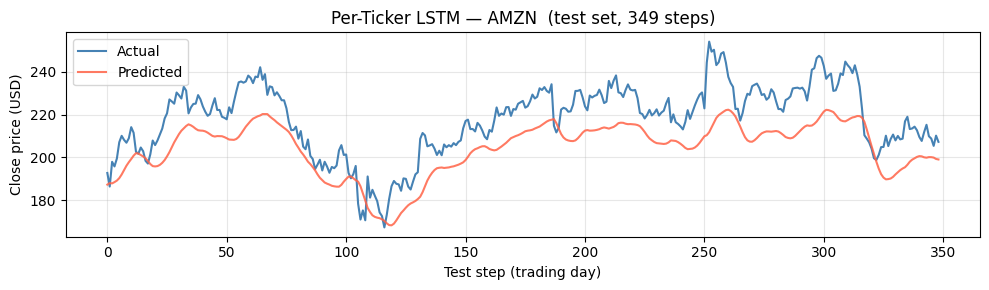

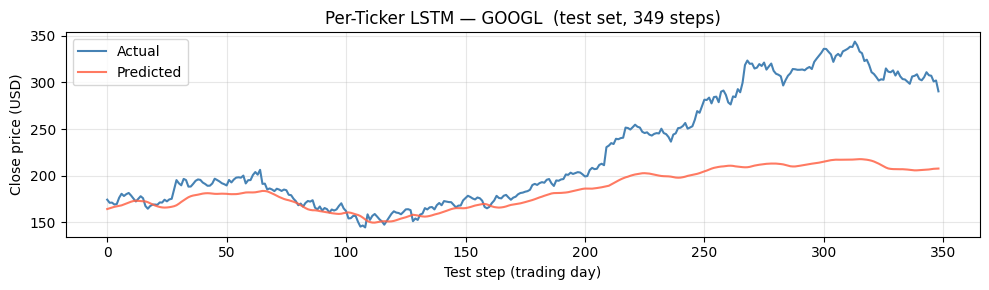

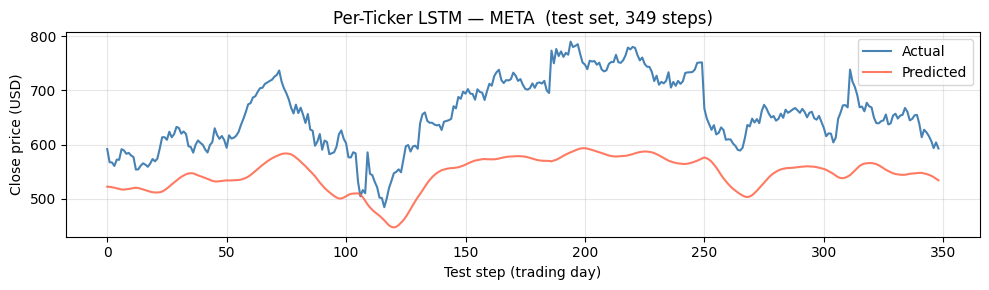

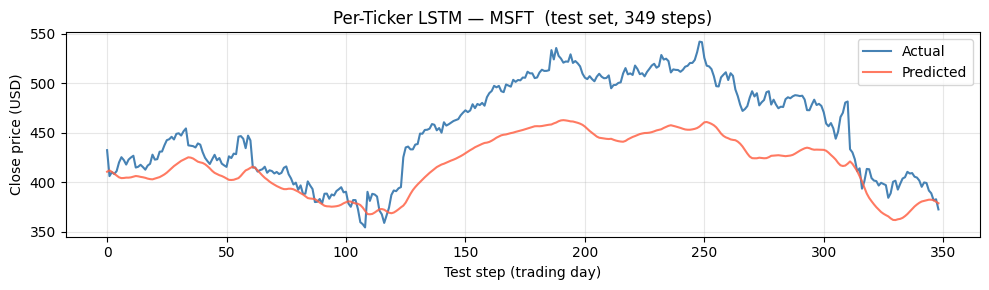

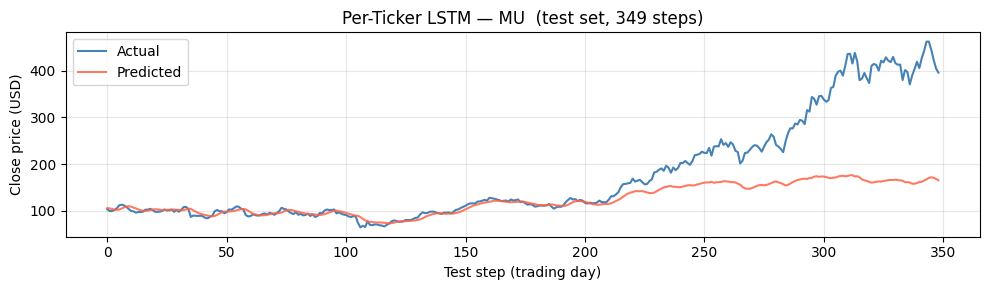

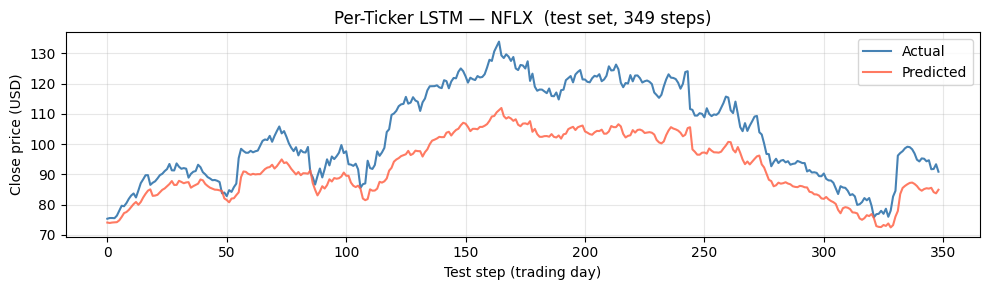

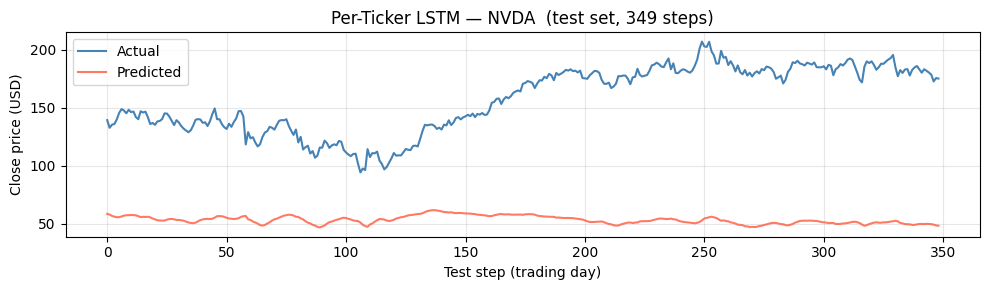

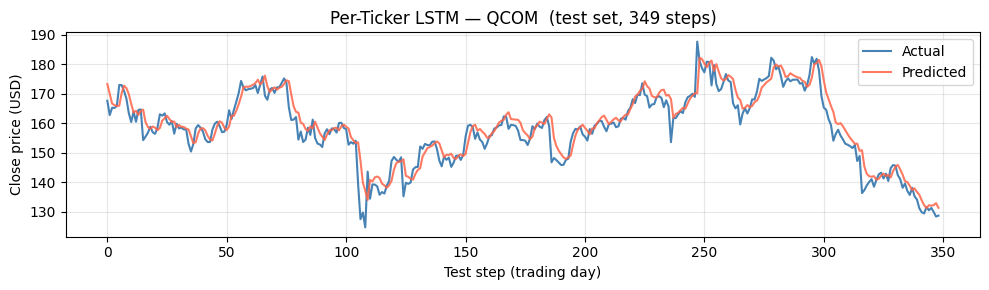


Per-Ticker LSTM — Summary metrics on test set
             MAE      RMSE  MAPE (%)  Directional Acc
Ticker                                               
AAPL     26.5204   30.0220   10.6954           0.4799
AMZN     13.7891   15.3600    6.2147           0.5086
GOOGL    39.6013   56.7121   14.4073           0.5086
META    109.7704  117.2858   16.3112           0.5230
MSFT     36.3192   42.1830    7.6387           0.5287
MU       53.7139   98.3159   18.3810           0.5115
NFLX     10.8516   12.2684    9.9482           0.5316
NVDA    103.6458  107.7721   64.6328           0.4713
QCOM      2.9507    4.1311    1.9050           0.4655


Comparison — Pooled vs Per-Ticker (MAPE %)
        Pooled MAPE (%)  Per-Ticker MAPE (%)      Winner
Ticker                                                  
AAPL             5.9404              10.6954      Pooled
AMZN             3.4288               6.2147      Pooled
GOOGL           10.6795              14.4073      Pooled
META            16.0818      

In [51]:
results_per_ticker = []

for i, ticker in enumerate(ticker_names):
    # Load the saved model for this ticker
    model_path = f"../models/{ticker}.lstm.keras"
    ticker_model = load_model(model_path)

    X_te = X_test_list[i]
    y_true_s = y_test_list[i].flatten()

    y_pred_s = ticker_model.predict(X_te, verbose=0).flatten()

    # Inverse-transform back to USD
    y_pred = inverse_transform_col(y_pred_s, scalers_list[i], target_idx, N_FEATURES)
    y_true = inverse_transform_col(y_true_s, scalers_list[i], target_idx, N_FEATURES)

    metrics = evaluate_forecast(y_true, y_pred)
    metrics["Ticker"] = ticker
    results_per_ticker.append(metrics)

    # Actual vs Predicted plot
    n = len(y_true)
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(y_true, label="Actual",    color="steelblue")
    ax.plot(y_pred, label="Predicted", color="tomato", alpha=0.85)
    ax.set_title(f"Per-Ticker LSTM — {ticker}  (test set, {n} steps)")
    ax.set_xlabel("Test step (trading day)")
    ax.set_ylabel("Close price (USD)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

df_per_ticker = pd.DataFrame(results_per_ticker).set_index("Ticker")
print("\nPer-Ticker LSTM — Summary metrics on test set")
print(df_per_ticker.to_string())

# ── Side-by-side comparison ───────────────────────────────────────────────────
print("\n\nComparison — Pooled vs Per-Ticker (MAPE %)")
comparison = pd.DataFrame({
    "Pooled MAPE (%)":     df_pooled["MAPE (%)"],
    "Per-Ticker MAPE (%)": df_per_ticker["MAPE (%)"],
})
comparison["Winner"] = comparison.idxmin(axis=1).str.replace(" MAPE \\(%\\)", "", regex=True)
print(comparison.to_string())

### 9. GRU Models — Pooled & Per-Ticker

**Architecture** — mirrors the LSTM section for a fair comparison:
- Two GRU layers (64 → 32 units) with Dropout(0.3)
- Huber loss, Adam(lr = 0.0005)
- Same HORIZON = 1, LOOKBACK = 30, per-ticker splits & scalers

Two variants:
1. **Pooled GRU** — all ticker sequences concatenated, one shared model.  
2. **Per-Ticker GRU** — one dedicated model per stock.

#### 9a. Pooled GRU

In [ ]:
import os
import keras
from keras.layers import Input, GRU, Dense, Dropout
import matplotlib.pyplot as plt

os.makedirs("../models", exist_ok=True)

n_features = len(FEATURE_COLS)

pooled_gru = keras.Sequential([
    Input(shape=(LOOKBACK, n_features)),
    GRU(64, return_sequences=True),
    Dropout(0.3),
    GRU(32, return_sequences=False),
    Dropout(0.3),
    Dense(HORIZON),
], name="pooled_gru")

pooled_gru.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss=keras.losses.Huber(),
)
pooled_gru.summary()

In [ ]:
# ── Callbacks ────────────────────────────────────────────────────────────────
gru_pooled_ckpt = keras.callbacks.ModelCheckpoint(
    "../models/pooled_gru.keras",
    monitor="val_loss", save_best_only=True, mode="min", verbose=0,
)
gru_pooled_es = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True,
)

# ── Train ────────────────────────────────────────────────────────────────────
gru_pooled_history = pooled_gru.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[gru_pooled_ckpt, gru_pooled_es],
    verbose=1,
)

# ── Loss curve ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gru_pooled_history.history["loss"],     label="train loss")
ax.plot(gru_pooled_history.history["val_loss"], label="val loss")
ax.set_title("Pooled GRU — Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Huber loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 9b. Per-Ticker GRU

One independent GRU is trained per stock using only that ticker's sequences.
Models are saved to `models/<TICKER>.gru.keras`.

In [ ]:
gru_ticker_histories = {}

for i, ticker in enumerate(ticker_names):
    X_tr = X_train_list[i]
    y_tr = y_train_list[i]
    X_va = X_val_list[i]
    y_va = y_val_list[i]

    model = keras.Sequential([
        Input(shape=(LOOKBACK, n_features)),
        GRU(64, return_sequences=True),
        Dropout(0.3),
        GRU(32, return_sequences=False),
        Dropout(0.3),
        Dense(HORIZON),
    ], name=f"gru_{ticker}")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss=keras.losses.Huber(),
    )

    ckpt = keras.callbacks.ModelCheckpoint(
        f"../models/{ticker}.gru.keras",
        monitor="val_loss", save_best_only=True, mode="min", verbose=0,
    )
    es = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True,
    )

    hist = model.fit(
        X_tr, y_tr,
        epochs=200,
        batch_size=32,
        validation_data=(X_va, y_va),
        callbacks=[ckpt, es],
        verbose=0,
    )
    gru_ticker_histories[ticker] = hist

    best_val = min(hist.history["val_loss"])
    stopped   = len(hist.history["loss"])
    print(f"{ticker:6s}  epochs={stopped:3d}  best_val_loss={best_val:.6f}")

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(hist.history["loss"],     label="train")
    ax.plot(hist.history["val_loss"], label="val")
    ax.set_title(f"Per-Ticker GRU — {ticker}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Huber loss")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\nAll per-ticker GRU models trained and saved to models/")

### 10. GRU — Test-Set Evaluation

Same inverse-transform approach as Section 8.  
Metrics: **MAE**, **RMSE**, **MAPE (%)**, **Directional Accuracy**.

#### 10a. Pooled GRU — test-set predictions

In [ ]:
y_pred_gru_pooled_scaled = pooled_gru.predict(X_test, verbose=0).flatten()
y_true_pooled_scaled      = y_test.flatten()

results_gru_pooled = []
offset = 0

for i, ticker in enumerate(ticker_names):
    n = X_test_list[i].shape[0]

    y_pred_s = y_pred_gru_pooled_scaled[offset : offset + n]
    y_true_s = y_true_pooled_scaled[offset : offset + n]

    y_pred = inverse_transform_col(y_pred_s, scalers_list[i], target_idx, N_FEATURES)
    y_true = inverse_transform_col(y_true_s, scalers_list[i], target_idx, N_FEATURES)

    metrics = evaluate_forecast(y_true, y_pred)
    metrics["Ticker"] = ticker
    results_gru_pooled.append(metrics)

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(y_true, label="Actual",    color="steelblue")
    ax.plot(y_pred, label="Predicted", color="orange", alpha=0.85)
    ax.set_title(f"Pooled GRU — {ticker}  (test set, {n} steps)")
    ax.set_xlabel("Test step (trading day)")
    ax.set_ylabel("Close price (USD)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    offset += n

df_gru_pooled = pd.DataFrame(results_gru_pooled).set_index("Ticker")
print("\nPooled GRU — Summary metrics on test set")
print(df_gru_pooled.to_string())

#### 10b. Per-Ticker GRU — test-set predictions

In [ ]:
results_gru_per_ticker = []

for i, ticker in enumerate(ticker_names):
    model_path = f"../models/{ticker}.gru.keras"
    gru_ticker_model = keras.models.load_model(model_path)

    X_te     = X_test_list[i]
    y_true_s = y_test_list[i].flatten()
    y_pred_s = gru_ticker_model.predict(X_te, verbose=0).flatten()

    y_pred = inverse_transform_col(y_pred_s, scalers_list[i], target_idx, N_FEATURES)
    y_true = inverse_transform_col(y_true_s, scalers_list[i], target_idx, N_FEATURES)

    metrics = evaluate_forecast(y_true, y_pred)
    metrics["Ticker"] = ticker
    results_gru_per_ticker.append(metrics)

    n = len(y_true)
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(y_true, label="Actual",    color="steelblue")
    ax.plot(y_pred, label="Predicted", color="tomato", alpha=0.85)
    ax.set_title(f"Per-Ticker GRU — {ticker}  (test set, {n} steps)")
    ax.set_xlabel("Test step (trading day)")
    ax.set_ylabel("Close price (USD)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

df_gru_per_ticker = pd.DataFrame(results_gru_per_ticker).set_index("Ticker")
print("\nPer-Ticker GRU — Summary metrics on test set")
print(df_gru_per_ticker.to_string())

### 11. All-Model Comparison

Side-by-side MAPE (%) for all four models:
- Pooled LSTM  
- Per-Ticker LSTM  
- Pooled GRU  
- Per-Ticker GRU

In [ ]:
comparison = pd.DataFrame({
    "Pooled LSTM MAPE (%)":      df_pooled["MAPE (%)"],
    "Per-Ticker LSTM MAPE (%)":  df_per_ticker["MAPE (%)"],
    "Pooled GRU MAPE (%)":       df_gru_pooled["MAPE (%)"],
    "Per-Ticker GRU MAPE (%)":   df_gru_per_ticker["MAPE (%)"],
})
comparison["Best Model"] = comparison.idxmin(axis=1).str.replace(" MAPE \\(%\\)", "", regex=True)

print("=== MAPE (%) Comparison — All Models on Test Set ===")
print(comparison.to_string())

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
comparison.drop(columns="Best Model").plot(kind="bar", ax=ax, rot=0)
ax.set_title("Test-Set MAPE (%) — All Models per Ticker")
ax.set_xlabel("Ticker")
ax.set_ylabel("MAPE (%)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Full metric tables ────────────────────────────────────────────────────────
for label, df in [
    ("Pooled LSTM",      df_pooled),
    ("Per-Ticker LSTM",  df_per_ticker),
    ("Pooled GRU",       df_gru_pooled),
    ("Per-Ticker GRU",   df_gru_per_ticker),
]:
    print(f"\n{'─'*60}")
    print(f"  {label}")
    print(f"{'─'*60}")
    print(df[["MAE", "RMSE", "MAPE (%)", "Directional Acc"]].to_string())

#### 12. REFLECTION ON THE USE OF LSTM AND GRU 

Cons: 
- Still not able to predict the stock price with high accuracy
- The model benefit greatly from 30-day lookback horizon = 1, but it does not deliver
much more striking performance than naive prediction (using previous day's close price) by comparing
the MAPE (%) of all models.

Pros: 
- LSTM and GRU are able to capture the stock price patterns and predict the stock price with
relatively high accuracy.
